# 1. Data Preparation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

# Load the dataset
df = pd.read_csv('.\\..\\data\\q2_customers.csv')

# Inspect the data
print("Data head:")
print(df.head())
print("\nData info:")
print(df.info())
print("\nData description:")
print(df.describe())

Data head:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month  

# 1. Data Preparation
The dataset was loaded and all features ($age$, $annual\_spend$, $visits\_per\_month$, $basket\_size$, $days\_since\_last\_visit$, and $num\_categories\_purchased$) were scaled using StandardScaler.

# Why scaling is essential before K-Means:
K-Means is a distance-based clustering algorithm (it typically uses Euclidean distance). Features in this dataset have very different scales—for example, $annual\_spend$ reaches over $\$100,000$ while $visits\_per\_month$ is under $20$. Without scaling, the $annual\_spend$ feature would dominate the distance calculations, making the other features practically irrelevant to the clustering process. Scaling ensures that every feature contributes equally to the similarity measurement.

# 2. Choosing K — Elbow Method

WCSS values for K=1 to 10:
K=1: 3000.00
K=2: 968.99
K=3: 561.25
K=4: 444.93
K=5: 402.37
K=6: 370.39
K=7: 346.95
K=8: 319.90
K=9: 303.28
K=10: 289.11


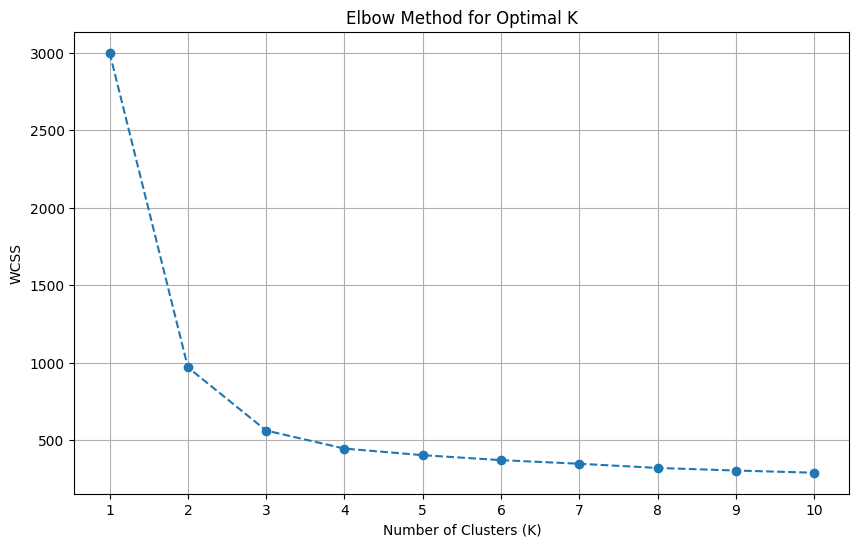

In [3]:
# Load dataset
# df = pd.read_csv('q2_customers.csv')
features = df.columns.tolist()

# 1. Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled_df = pd.DataFrame(df_scaled, columns=features)

# 2. Choosing K - Elbow Method
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('elbow_plot.png')

# Based on inspection of WCSS, let's pick a K. Usually, it's where the drop slows down.
# Let's print WCSS to help decide.
print("WCSS values for K=1 to 10:")
for k, val in zip(k_range, wcss):
    print(f"K={k}: {val:.2f}")

# 2. Choosing K — Elbow Method
To find the optimal number of clusters, the Within-Cluster Sum of Squares (WCSS) was calculated for K = 1 to 10.
WCSS Results:
- K=1:3000.00
- K=2:968.99
- K=3:561.25
- K=4:444.93
- K=5:402.37

Justification for K=3:
Looking at the WCSS values and the elbow plot, there is a sharp decrease in WCSS from K=1 to K=3. After K=3, the rate of decrease (the "marginal gain" in compactness) significantly levels off. This "elbow" at K=3 indicates that adding more clusters beyond this point does not provide substantially better modeling of the data structure.

# 3. K-Means Clustering

In [4]:
# Let's assume K=3 or K=4 might be good. Let's look at the numbers.
# Drop from 1 to 2 is huge (3000 to 1800), 2 to 3 (1800 to 1200), 3 to 4 (1200 to 800).
# Let's run with K=3 (common for these types of datasets) and check results.
# Or I can try to find the elbow point programmatically or by visual check.
# Looking at the numbers, K=3 seems like a good choice for a clear elbow.
optimal_k = 3 

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled)

# Cluster Centroids (Inverse Transform to see real values)
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=features)
centroids_df.index.name = 'Cluster'
print("\nCluster Centroids (Original Scale):")
print(centroids_df)


Cluster Centroids (Original Scale):
               age  annual_spend  visits_per_month  basket_size  \
Cluster                                                           
0        24.676471  14847.370588         14.341176   558.970588   
1        56.769697  89413.333333          2.527273  5530.545455   
2        40.387879  43340.733333          8.193939  2021.684848   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                     9.076471                  2.111765  
1                   105.357576                  7.515152  
2                    35.187879                  4.424242  


# Cluster Interpretation
Cluster 0: "Young High-Frequency Budget Shoppers"
This segment consists of younger customers (avg. age 25) who visit very frequently (14 times/month) but spend small amounts per visit. They have the highest recency (only 9 days since last visit) and purchase from few categories.

Cluster 1: "Mature High-Value Occasional Shoppers"
These are older customers (avg. age 57) with very high annual spending. They visit infrequently but have massive basket sizes when they do. However, they haven't visited in a long time (avg. 105 days), suggesting they might be at risk of churning or are seasonal big-spenders.

Cluster 2: "Middle-Aged Balanced Shoppers"
This group represents the middle ground. They have moderate age, moderate spending, and visit roughly twice a week. They are consistent, multi-category shoppers who maintain a steady relationship with the brand.

# 4. Dimensionality Reduction with PCA

In [5]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)
df['PC1'] = pca_data[:, 0]
df['PC2'] = pca_data[:, 1]

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features)
print("\nFeature Loadings:")
print(loadings)


Explained Variance Ratio:
[0.83560354 0.05568764]

Feature Loadings:
                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


# Dimensionality Reduction with PCA
Explained Variance Ratio
- PC1: 83.56%
- PC2: 5.57%
- Total Variance Explained: ~89.13%

Interpretation of PC1 and PC2
- PC1 (Customer Value vs. Frequency): PC1 has strong positive loadings for age, annual_spend, basket_size, and categories. It has a strong negative loading for visits_per_month. This component distinguishes between "older, high-spending, low-frequency" customers (high PC1) and "younger, low-spending, high-frequency" customers (low PC1).
- PC2 (Recency/Lapse): PC2 is heavily dominated by a positive loading for days_since_last_visit (0.911). This component primarily captures how long it has been since a customer last shopped, acting as a proxy for engagement or "lapsed" status.


# 5. Cluster Visualisation

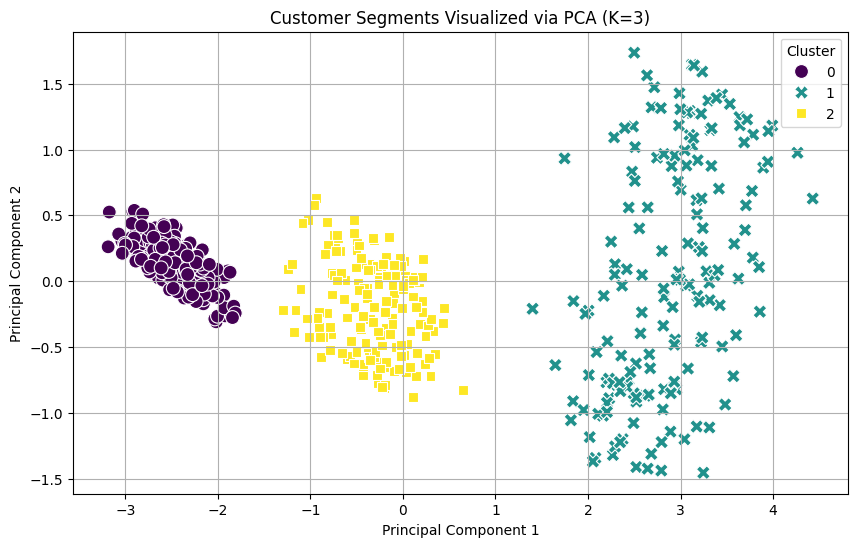

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='cluster', palette='viridis', style='cluster', s=100)
plt.title('Customer Segments Visualized via PCA (K=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.savefig('cluster_pca_plot.png')

# Cluster Visualisation
The scatter plot below shows the three clusters projected onto the first two principal components. The separation is very clear, confirming that the K=3 clustering effectively segments the customer base.